In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

from statsmodels.tsa.seasonal import seasonal_decompose

In [6]:
day1 = pd.read_csv("Aqi_Data_One_Day_Prediction.csv",index_col="time", parse_dates=True)

In [7]:
day1.head()

,temperature_2m,wind_speed_10m,relative_humidity_2m,surface_pressure,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,...,dayofweek,quarter,previous_hour_aqi,previous_day_aqi,aqi_change_rate,rolled_mean_aqi_6hr,rolled_mean_aqi_24hr,rolled_mean_aqi_72hr,ewm_aqi_24hr,Day_1_Future_AQI
time,,,,,,,,,,,,,,,,,,,,,
2023-08-04 00:00:00+05:00,27.4,18.7,90,1000.1,95.2,27.5,179.0,12.0,4.2,42.0,...,4,3,78.0,73.0,0.0,76.166667,74.333333,73.444444,74.691898,83.0
2023-08-04 01:00:00+05:00,27.2,19.0,90,999.3,90.8,26.6,157.0,10.0,3.9,43.0,...,4,3,78.0,73.0,1.0,76.666667,74.541667,73.513889,74.957149,83.0
2023-08-04 02:00:00+05:00,27.0,17.7,92,998.6,91.7,26.2,138.0,8.3,3.7,44.0,...,4,3,79.0,73.0,0.0,77.333333,74.791667,73.597222,75.281255,83.0
2023-08-04 03:00:00+05:00,26.9,17.1,92,998.7,98.7,26.8,123.0,7.0,3.6,45.0,...,4,3,79.0,73.0,0.0,77.833333,75.041667,73.680556,75.579328,83.0
2023-08-04 04:00:00+05:00,27.0,20.0,92,998.8,104.5,27.1,112.0,6.0,3.6,45.0,...,4,3,79.0,73.0,1.0,78.333333,75.291667,73.763889,75.853467,82.0


In [8]:
day1.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26232 entries, 2023-08-04 00:00:00+05:00 to 2026-07-31 23:00:00+05:00
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   temperature_2m        26232 non-null  float64
 1   wind_speed_10m        26232 non-null  float64
 2   relative_humidity_2m  26232 non-null  int64  
 3   surface_pressure      26232 non-null  float64
 4   pm10                  26232 non-null  float64
 5   pm2_5                 26232 non-null  float64
 6   carbon_monoxide       26232 non-null  float64
 7   nitrogen_dioxide      26232 non-null  float64
 8   sulphur_dioxide       26232 non-null  float64
 9   ozone                 26232 non-null  float64
 10  us_aqi                26232 non-null  int64  
 11  hour                  26232 non-null  int64  
 12  day                   26232 non-null  int64  
 13  month                 26232 non-null  int64  
 14  dayofweek             2

# Summary Statistics

In [9]:
day1.describe()

,temperature_2m,wind_speed_10m,relative_humidity_2m,surface_pressure,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,...,dayofweek,quarter,previous_hour_aqi,previous_day_aqi,aqi_change_rate,rolled_mean_aqi_6hr,rolled_mean_aqi_24hr,rolled_mean_aqi_72hr,ewm_aqi_24hr,Day_1_Future_AQI
count,26232.000000,26232.000000,26232.000000,26232.000000,26232.000000,26232.000000,26232.000000,26232.000000,26232.000000,26232.000000,...,26232.000000,26232.000000,26232.000000,26232.000000,26232.000000,26232.000000,26232.000000,26232.000000,26232.000000,26232.000000
mean,26.614989,13.431763,65.218474,1007.842174,61.619057,28.273346,460.623933,19.315081,12.715622,72.217635,...,3.000915,2.506862,88.264829,88.252440,0.000496,88.263393,88.258312,88.249504,88.258764,88.272072
std,4.805035,6.592557,21.383366,6.794293,36.235056,13.425372,404.952273,18.209475,8.489513,38.983720,...,1.999352,1.118443,23.477388,23.481011,3.020655,23.160648,22.263614,20.392426,21.809233,23.476728
min,9.300000,0.000000,5.000000,990.100000,3.700000,3.500000,46.000000,0.000000,2.300000,0.000000,...,0.000000,1.000000,41.000000,41.000000,-34.000000,42.500000,46.958333,51.319444,48.385468,41.000000
25%,23.900000,8.600000,51.000000,1002.500000,39.200000,19.200000,209.000000,7.200000,5.900000,44.000000,...,1.000000,2.000000,72.000000,72.000000,0.000000,71.833333,72.416667,73.375000,72.711899,72.000000
50%,27.500000,12.400000,70.000000,1008.000000,53.600000,24.800000,306.000000,12.700000,10.900000,63.000000,...,3.000000,3.000000,82.000000,82.000000,0.000000,82.500000,83.041667,83.888889,83.178461,82.000000
75%,29.900000,17.100000,83.000000,1013.600000,73.800000,33.600000,571.000000,24.900000,16.700000,95.000000,...,5.000000,4.000000,99.000000,99.000000,0.000000,98.666667,98.666667,99.003472,98.554252,99.000000
max,41.600000,46.600000,100.000000,1024.200000,504.800000,117.800000,4515.000000,154.100000,65.400000,240.000000,...,6.000000,4.000000,185.000000,185.000000,33.000000,183.833333,181.208333,174.083333,179.662111,185.000000


# Simple Plot

<Axes: xlabel='time'>

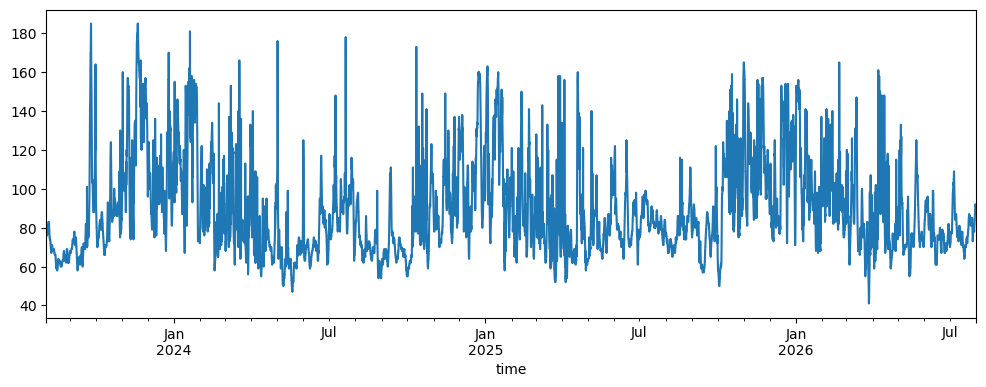

In [17]:
day1["Day_1_Future_AQI"].plot(figsize=(12,4))

<Axes: xlabel='time'>

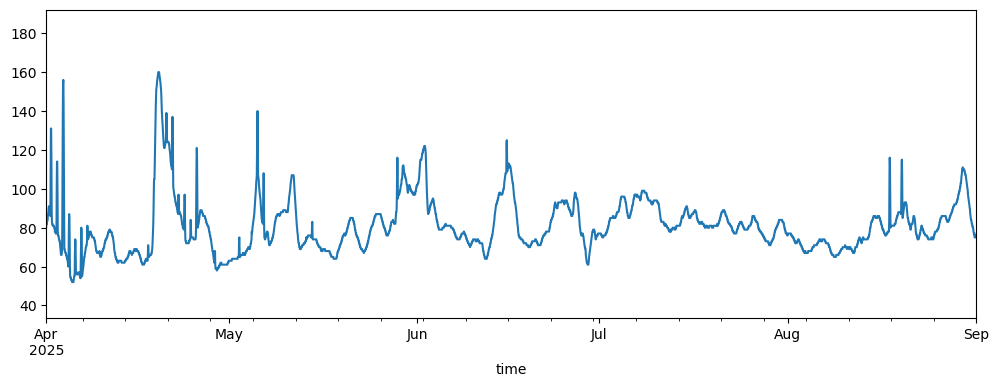

In [23]:
day1["Day_1_Future_AQI"].plot(xlim = ['2025-04-01','2025-09-01'], figsize=(12,4))

# Note:
1. The AQI is low from May to October as compare to Winter Seasons.
2. There is a seasonal pattern and residual.
3. The highest AQI is 185 and lowest is 41.
4. Daily cycles are also visible.

# AQI Category Understanding

In [24]:
day1["us_aqi"].max()

185

In [25]:
day1["us_aqi"].min()

41

In [26]:
labels = ["Good", "Moderate", "Unhealthy for Sensitive", "Unhealthy", "Very Unhealthy", "Hazardous"]
bins = [0, 50, 100, 150, 200, 300, 500]

day1['AQI-Category'] = pd.cut(day1["us_aqi"],bins,labels=labels,include_lowest=True)

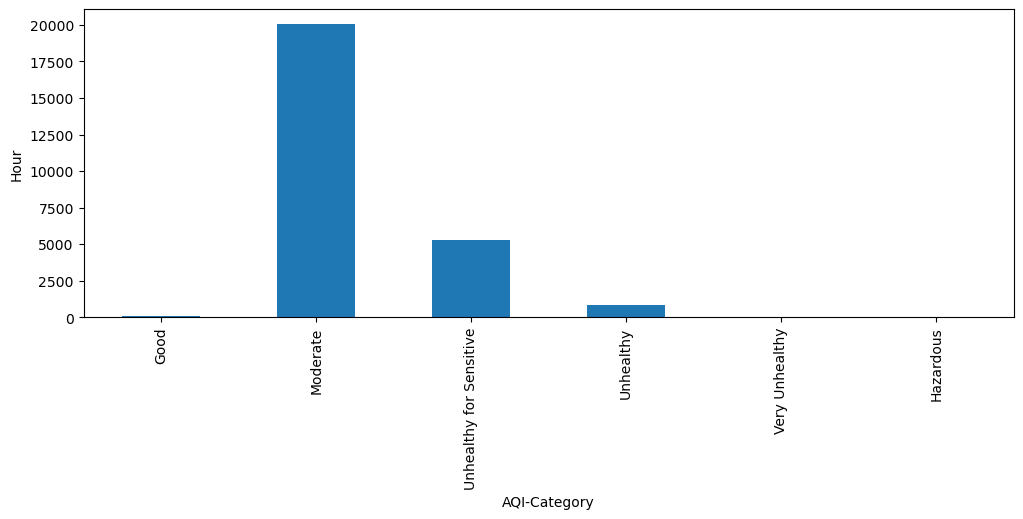

In [39]:
day1['AQI-Category'].value_counts().sort_index().plot(kind='bar', figsize=(12,4))
plt.ylabel('Hour')
plt.show()

In [41]:
day1.head()

,temperature_2m,wind_speed_10m,relative_humidity_2m,surface_pressure,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,...,quarter,previous_hour_aqi,previous_day_aqi,aqi_change_rate,rolled_mean_aqi_6hr,rolled_mean_aqi_24hr,rolled_mean_aqi_72hr,ewm_aqi_24hr,Day_1_Future_AQI,AQI-Category
time,,,,,,,,,,,,,,,,,,,,,
2023-08-04 00:00:00+05:00,27.4,18.7,90,1000.1,95.2,27.5,179.0,12.0,4.2,42.0,...,3,78.0,73.0,0.0,76.166667,74.333333,73.444444,74.691898,83.0,Moderate
2023-08-04 01:00:00+05:00,27.2,19.0,90,999.3,90.8,26.6,157.0,10.0,3.9,43.0,...,3,78.0,73.0,1.0,76.666667,74.541667,73.513889,74.957149,83.0,Moderate
2023-08-04 02:00:00+05:00,27.0,17.7,92,998.6,91.7,26.2,138.0,8.3,3.7,44.0,...,3,79.0,73.0,0.0,77.333333,74.791667,73.597222,75.281255,83.0,Moderate
2023-08-04 03:00:00+05:00,26.9,17.1,92,998.7,98.7,26.8,123.0,7.0,3.6,45.0,...,3,79.0,73.0,0.0,77.833333,75.041667,73.680556,75.579328,83.0,Moderate
2023-08-04 04:00:00+05:00,27.0,20.0,92,998.8,104.5,27.1,112.0,6.0,3.6,45.0,...,3,79.0,73.0,1.0,78.333333,75.291667,73.763889,75.853467,82.0,Moderate


In [37]:
day1['AQI-Category'].value_counts()

AQI-Category
Moderate                   20064
Unhealthy for Sensitive     5286
Unhealthy                    818
Good                          64
Very Unhealthy                 0
Hazardous                      0
Name: count, dtype: int64

In [38]:
day1['AQI-Category'].value_counts()/len(day1["us_aqi"])*100

AQI-Category
Moderate                   76.486734
Unhealthy for Sensitive    20.150961
Unhealthy                   3.118329
Good                        0.243977
Very Unhealthy              0.000000
Hazardous                   0.000000
Name: count, dtype: float64

# Note:
1. Moderate(51-100): 76.5% of hours have a moderate AQI level. This is Karachi's typical air quality.
2. Unhealthy for Sensitive(101-150): Unhealthy for Sensitive is about 20.15%, meaning sensitive groups face air quality concerns roughly one-fifth of the time.
3. Unhealthy(151-200): Unhealthy is about 3.11%, but is serious mostly are short length pollutant events.
4. No record for Very Unhealthy and Hazardous.

# Correlation Understanding

<Axes: >

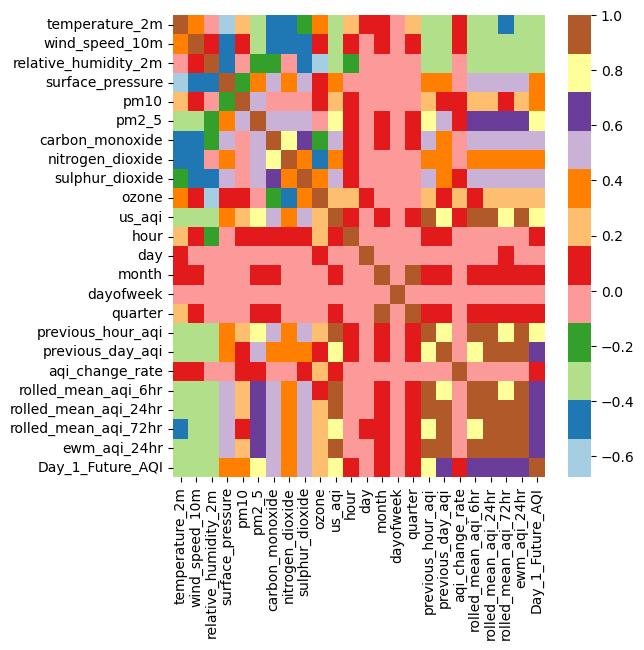

In [50]:
plt.figure(figsize=(6,6))
sns.heatmap(day1.corr(numeric_only=True),cmap="Paired")

# Note:
1. There are only two predictors with strong predictive power: previous_day_aqi and rolling means correlate bemost with the target, validating our  feature engineering choices.
2. Pollutant correlations are structural: us_aqi is calculated from pollutants; they are related to each other through this structure. 
   All they are asking are that they be shown the formula, which is the correlation, rather than any new insight.
3. near zero linear correlation between temporal features: But they do count — hour and month 
   Avoid correlation, as it doesn't have cyclical patterns. This can be proven from the hourly and monthly plots.
4. Wind speeds have a negative relationship with AQI as they break pollution.

# Lets Check Min And Max Of Each Year

In [52]:
day1.resample(rule = 'YE').min()

,temperature_2m,wind_speed_10m,relative_humidity_2m,surface_pressure,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,...,quarter,previous_hour_aqi,previous_day_aqi,aqi_change_rate,rolled_mean_aqi_6hr,rolled_mean_aqi_24hr,rolled_mean_aqi_72hr,ewm_aqi_24hr,Day_1_Future_AQI,AQI-Category
time,,,,,,,,,,,,,,,,,,,,,
2023-12-31 00:00:00+05:00,13.2,0.4,6,997.4,15.0,10.2,74.0,2.4,2.5,4.0,...,3,58.0,58.0,-27.0,58.166667,59.000000,60.305556,59.093536,58.0,Moderate
2024-12-31 00:00:00+05:00,10.0,0.0,5,990.1,6.9,4.7,46.0,0.7,2.3,0.0,...,1,47.0,47.0,-29.0,47.000000,48.083333,51.319444,48.771322,47.0,Good
2025-12-31 00:00:00+05:00,11.5,0.2,5,992.7,3.9,3.8,74.0,1.5,4.9,0.0,...,1,50.0,50.0,-34.0,50.000000,50.916667,54.750000,51.917006,50.0,Good
2026-12-31 00:00:00+05:00,9.3,0.2,7,993.3,3.7,3.5,91.0,0.0,2.9,0.0,...,1,41.0,41.0,-26.0,42.500000,46.958333,60.263889,48.385468,41.0,Good


In [53]:
day1.resample(rule = 'YE').max()

,temperature_2m,wind_speed_10m,relative_humidity_2m,surface_pressure,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,...,quarter,previous_hour_aqi,previous_day_aqi,aqi_change_rate,rolled_mean_aqi_6hr,rolled_mean_aqi_24hr,rolled_mean_aqi_72hr,ewm_aqi_24hr,Day_1_Future_AQI,AQI-Category
time,,,,,,,,,,,,,,,,,,,,,
2023-12-31 00:00:00+05:00,39.5,39.3,100,1021.4,497.3,117.8,2168.0,119.7,60.4,207.0,...,4,185.0,185.0,26.0,183.833333,181.208333,174.083333,179.662111,185.0,Unhealthy
2024-12-31 00:00:00+05:00,41.6,46.6,100,1023.3,448.9,91.5,4302.0,154.1,55.1,240.0,...,4,181.0,181.0,33.0,167.000000,159.166667,157.388889,158.576281,181.0,Unhealthy
2025-12-31 00:00:00+05:00,40.2,26.8,99,1022.0,385.6,108.7,4515.0,138.5,65.4,213.0,...,4,165.0,165.0,32.0,164.333333,162.625000,150.902778,158.489843,165.0,Unhealthy
2026-12-31 00:00:00+05:00,41.2,25.0,100,1024.2,504.8,95.9,3219.0,128.8,56.3,203.0,...,3,165.0,165.0,24.0,155.166667,153.625000,150.930556,152.928027,165.0,Unhealthy


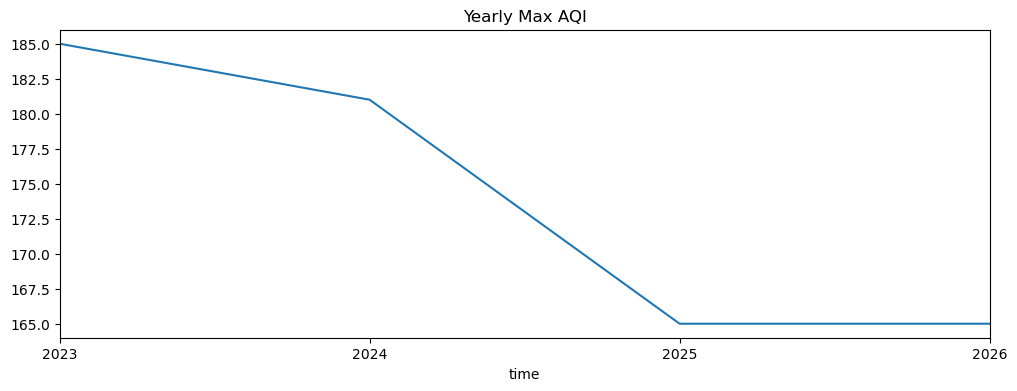

In [57]:
day1["us_aqi"].resample(rule='YE').max().plot(figsize=(12,4))
plt.title("Yearly Max AQI")
plt.show()

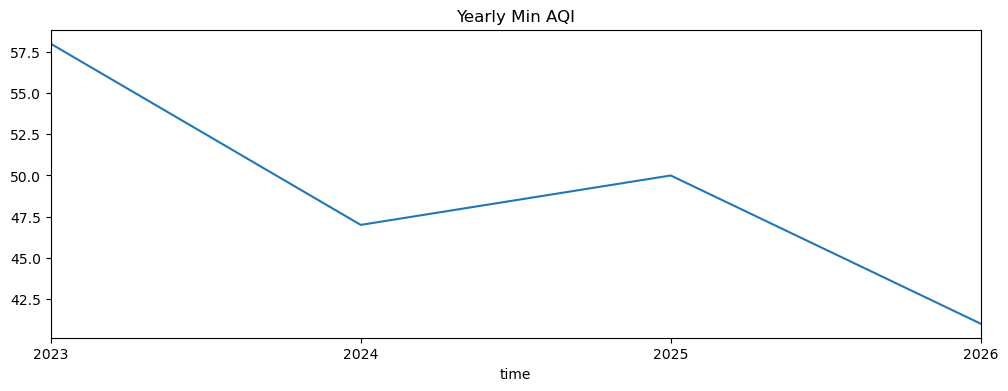

In [58]:
day1["us_aqi"].resample(rule='YE').min().plot(figsize=(12,4))
plt.title("Yearly Min AQI")
plt.show()

# Note:
- So the above chart shows the yearly min and max aqi. As you can see in yearly max graph the aqi is constant from 2025 to 2026. Also
from 2023 till early 2024 AQI was highest, then it went down.
- And for the minimum chart, lowest AQI is in a current year 2026.
- But 2023 only covers from August to December, and 2026 from January to July, so the comparison does not seems right. The line is going
  down because data is incomplete.

# Temporal Patterns

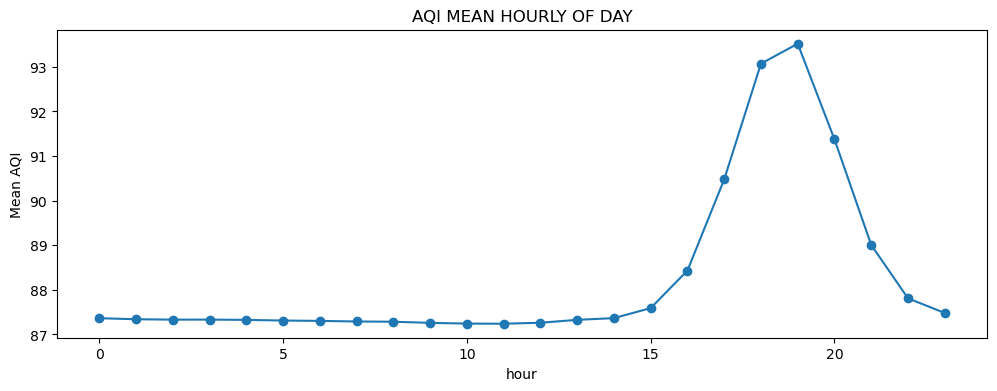

In [62]:
plt.figure(figsize=(12,4))
day1.groupby("hour")["us_aqi"].mean().plot(figsize=(12,4), marker="o")
plt.title("AQI MEAN HOURLY OF DAY")
plt.ylabel("Mean AQI")
plt.show()

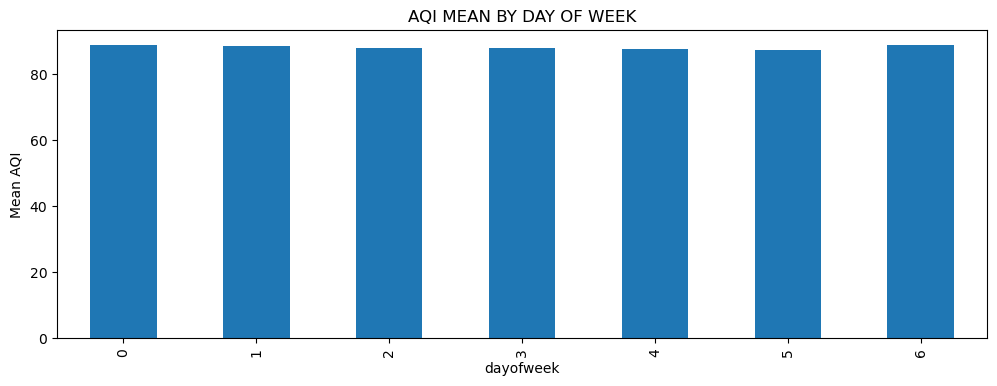

In [63]:
plt.figure(figsize=(12,4))
day1.groupby("dayofweek")["us_aqi"].mean().plot(kind = 'bar')
plt.title("AQI MEAN BY DAY OF WEEK")
plt.ylabel("Mean AQI")
plt.show()

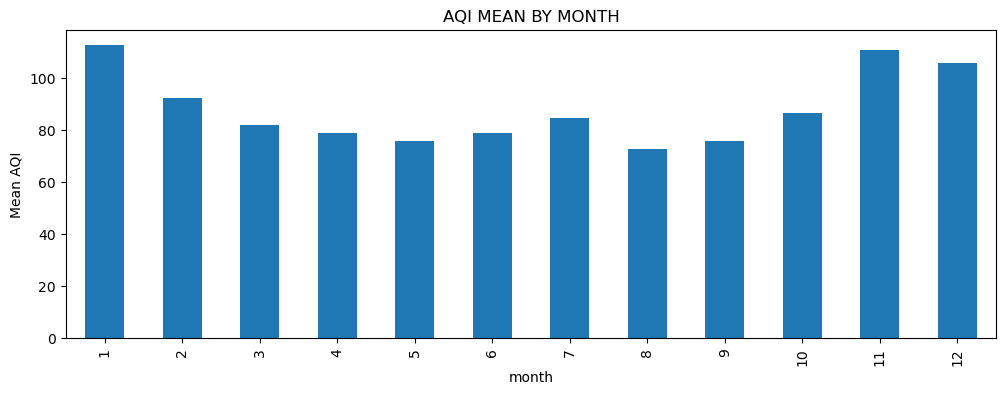

In [64]:
plt.figure(figsize=(12,4))
day1.groupby("month")["us_aqi"].mean().plot(kind = 'bar')
plt.title("AQI MEAN BY MONTH")
plt.ylabel("Mean AQI")
plt.show()

# Seasonal Decomposition

In [91]:
result = seasonal_decompose(day1['us_aqi'], model='additive', period=24)

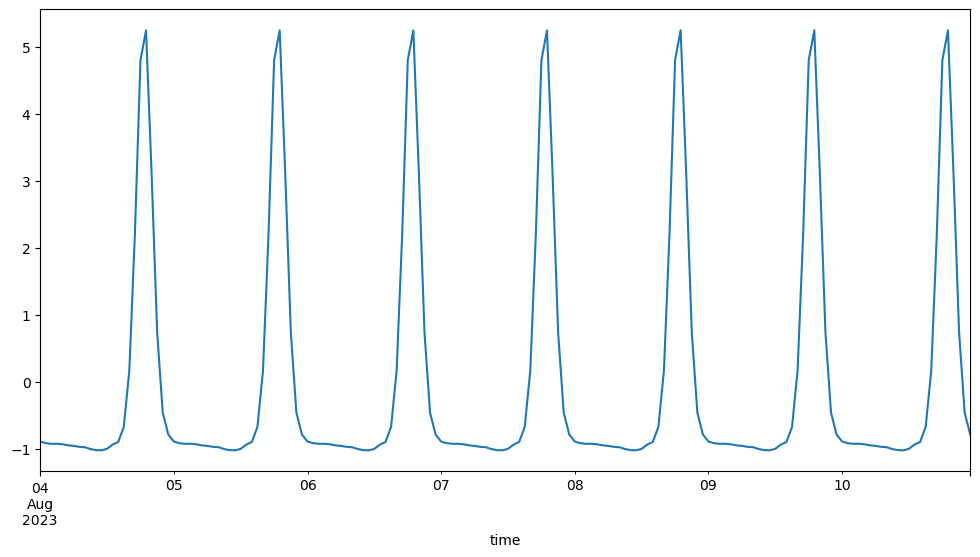

In [98]:
result.seasonal[:168].plot(figsize=(12, 6))
plt.show()

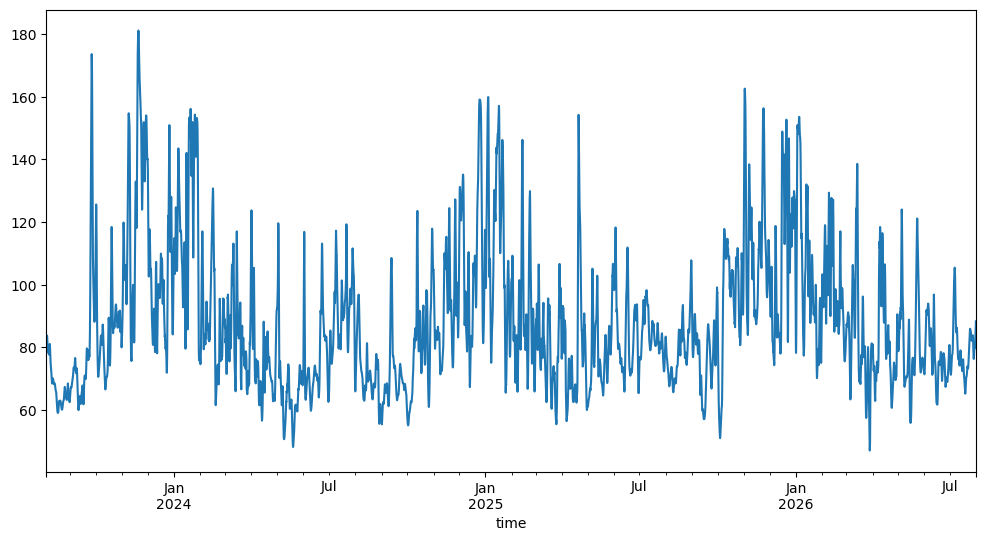

In [101]:
result.trend.plot(figsize=(12, 6))
plt.show()

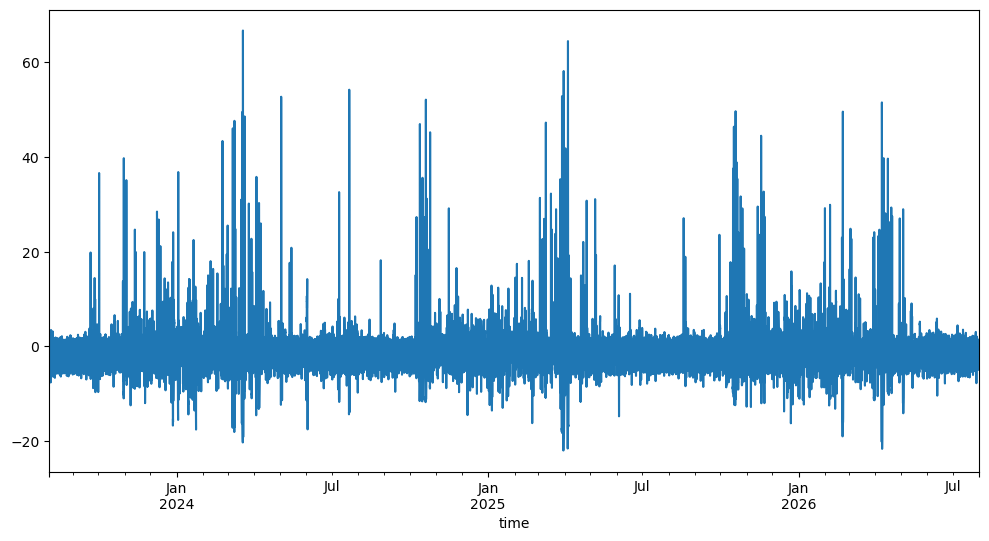

In [103]:
result.resid.plot(figsize=(12, 6))
plt.show()